# make_B_mask_8km

Generate `B_mask_8km.nc` by nearest-neighbour regridding from `B_mask_25km.nc`, then validate and plot the result.

In [15]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import os
import warnings
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import xarray as xr
import cartopy.crs as ccrs

warnings.filterwarnings('ignore', message="Engine 'argo' loading failed.*", category=RuntimeWarning)

In [16]:
WORKDIR = Path ('/g/data/tm70/ek4684/make_OM3_025deg_topo_26_11_25/')
SOURCE_MASK_FILE = WORKDIR / 'B_mask_25km.nc'
SOURCE_HGRID_FILE = Path('/g/data/vk83/configurations/inputs/access-om3/mom/grids/mosaic/global.25km/2025.09.02/ocean_hgrid.nc')
TARGET_HGRID_FILE = Path('/g/data/tm70/ek4684/8km_grid_input_files/ocean_hgrid.nc')

OUTPUT_MASK_FILE = WORKDIR / 'B_mask_8km.nc'
FORWARD_WEIGHTS_FILE = WORKDIR / 'B_mask_25km_to_8km_nearest_s2d_weights.nc'
BACK_WEIGHTS_FILE = WORKDIR / 'B_mask_8km_to_25km_nearest_s2d_weights.nc'
COMPARISON_PLOT_FILE = WORKDIR / 'B_mask_25km_vs_8km.png'

FORCE_REGRID = False
PLOT_CENTRAL_LONGITUDE = -100

In [17]:
def md5sum(path, blocksize=1024 * 1024):
    digest = hashlib.md5()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(blocksize), b''):
            digest.update(block)
    return digest.hexdigest()


def tracer_grid_from_mom_supergrid(path):
    hgrid = xr.open_dataset(path, decode_times=False)
    lon = hgrid['x'].isel(nyp=slice(1, None, 2), nxp=slice(1, None, 2)).rename({'nyp': 'ny', 'nxp': 'nx'})
    lat = hgrid['y'].isel(nyp=slice(1, None, 2), nxp=slice(1, None, 2)).rename({'nyp': 'ny', 'nxp': 'nx'})
    return xr.Dataset({'lon': lon, 'lat': lat})


def coarsen_for_plot(mask, lon, lat, factor=2):
    trim_y = (mask.sizes['ny'] // factor) * factor
    trim_x = (mask.sizes['nx'] // factor) * factor
    mask_c = mask.isel(ny=slice(0, trim_y), nx=slice(0, trim_x)).coarsen(ny=factor, nx=factor, boundary='trim').max()
    lon_c = lon.isel(ny=slice(0, trim_y), nx=slice(0, trim_x)).coarsen(ny=factor, nx=factor, boundary='trim').mean()
    lat_c = lat.isel(ny=slice(0, trim_y), nx=slice(0, trim_x)).coarsen(ny=factor, nx=factor, boundary='trim').mean()
    return mask_c, lon_c, lat_c


def import_xesmf():
    os.environ.setdefault('NUMBA_DISABLE_COVERAGE', '1')
    try:
        import xesmf as xe
    except Exception as exc:
        raise RuntimeError('Could not import xesmf. Use analysis3-25.11 to regenerate, or keep FORCE_REGRID=False.') from exc
    return xe


def plot_crs():
    return ccrs.PlateCarree(central_longitude=PLOT_CENTRAL_LONGITUDE)


def add_grid(ax):
    return ax.gridlines(linewidth=0.35, color='0.45', alpha=0.6, linestyle='--')


def pcolormesh_mask(ax, lon, lat, mask, **kwargs):
    return ax.pcolormesh(lon.values, lat.values, mask.values, transform=plot_crs(), shading='auto', vmin=0, vmax=1, **kwargs)


def contour_boundary(ax, lon, lat, mask, color, linewidth=1.0):
    return ax.contour(lon.values, lat.values, mask.values, levels=[0.5], colors=color, linewidths=linewidth, transform=plot_crs())

In [18]:
source_mask = xr.open_dataset(SOURCE_MASK_FILE, decode_times=False)['B_mask']
source_grid = tracer_grid_from_mom_supergrid(SOURCE_HGRID_FILE)
target_grid = tracer_grid_from_mom_supergrid(TARGET_HGRID_FILE)

print('source mask:', source_mask.shape, source_mask.dtype)
print('source tracer grid:', source_grid.lon.shape)
print('target tracer grid:', target_grid.lon.shape)
print('source lat range:', float(source_grid.lat.min()), float(source_grid.lat.max()))
print('target lat range:', float(target_grid.lat.min()), float(target_grid.lat.max()))

assert source_mask.shape == source_grid.lon.shape
assert target_grid.lon.shape == (3672, 4320)
assert set(np.unique(source_mask.values).tolist()) <= {0, 1}

source mask: (1152, 1440) int8
source tracer grid: (1152, 1440)
target tracer grid: (3672, 4320)
source lat range: -81.58497619628906 89.94100189208984
target lat range: -86.48922074955406 89.98009621609103


## Generate

In [19]:
xe = import_xesmf()
regridder = xe.Regridder(
        source_grid,
        target_grid,
        method='nearest_s2d',
        extrap_method='nearest_s2d',
        filename=str(FORWARD_WEIGHTS_FILE),
        reuse_weights=FORWARD_WEIGHTS_FILE.exists(),
    )
B_mask_8km = xr.DataArray(
        (regridder(source_mask) >= 0.5).astype('int8').data,
        dims=('ny', 'nx'),
        name='B_mask',
        attrs=dict(source_mask.attrs),
    )
B_mask_8km = B_mask_8km.where(target_grid.lat >= float(source_grid.lat.min()), 1).astype('int8')
B_mask_8km.attrs['regrid_method'] = 'ESMF nearest_s2d from B_mask_25km.nc; target cells south of the 25 km source grid set to 1'

output = xr.Dataset({'B_mask': B_mask_8km})
output.attrs['title'] = 'ACCESS-OM3 8km B-grid topography mask'
output.attrs['source_mask_file'] = f'{SOURCE_MASK_FILE} (md5sum:{md5sum(SOURCE_MASK_FILE)})'
output.attrs['source_hgrid_file'] = f'{SOURCE_HGRID_FILE} (md5sum:{md5sum(SOURCE_HGRID_FILE)})'
output.attrs['target_hgrid_file'] = f'{TARGET_HGRID_FILE} (md5sum:{md5sum(TARGET_HGRID_FILE)})'
output.attrs['history'] = f"Created on {datetime.now(timezone.utc).isoformat()} by make_B_mask_8km.ipynb using xESMF/ESMF nearest_s2d"
output.to_netcdf(OUTPUT_MASK_FILE, encoding={'B_mask': {'zlib': True, 'complevel': 9}})

B_mask_8km = xr.open_dataset(OUTPUT_MASK_FILE, decode_times=False)['B_mask']
values, counts = np.unique(B_mask_8km.values, return_counts=True)
print('output shape:', B_mask_8km.shape)
print('output dtype:', B_mask_8km.dtype)
print('output counts:', dict(zip(values.tolist(), counts.tolist())))

assert B_mask_8km.shape == target_grid.lon.shape
assert set(values.tolist()) <= {0, 1}

output shape: (3672, 4320)
output dtype: int8
output counts: {0: 7668419, 1: 8194621}


## Validation

In [20]:
try:
    xe = import_xesmf()
    back_regridder = xe.Regridder(
        target_grid,
        source_grid,
        method='nearest_s2d',
        extrap_method='nearest_s2d',
        filename=str(BACK_WEIGHTS_FILE),
        reuse_weights=BACK_WEIGHTS_FILE.exists(),
    )
    roundtrip = (back_regridder(B_mask_8km) >= 0.5).astype('int8')
    diff = roundtrip - source_mask
    values, counts = np.unique(diff.values, return_counts=True)
    print('round-trip diff counts:', dict(zip(values.tolist(), counts.tolist())))
except RuntimeError as exc:
    print(f'Skipping round-trip check: {exc}')

round-trip diff counts: {0: 1658880}


## Map Check

PosixPath('/g/data/tm70/ek4684/make_OM3_025deg_topo_26_11_25/B_mask_25km_vs_8km.png')

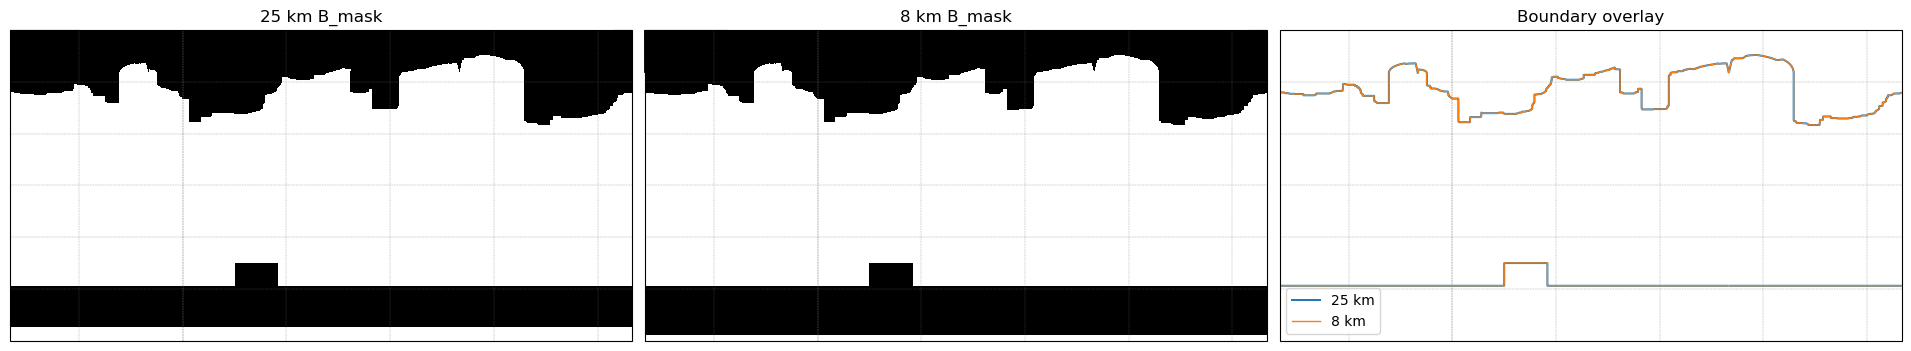

In [23]:
plot_mask_8km, plot_lon_8km, plot_lat_8km = coarsen_for_plot(B_mask_8km, target_grid.lon, target_grid.lat, factor=2)

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), subplot_kw={'projection': plot_crs()}, constrained_layout=True)
for ax in axes:
    ax.set_global()
    add_grid(ax)

pcolormesh_mask(axes[0], source_grid.lon, source_grid.lat, source_mask, cmap='Greys')
axes[0].set_title('25 km B_mask')

pcolormesh_mask(axes[1], plot_lon_8km, plot_lat_8km, plot_mask_8km, cmap='Greys')
axes[1].set_title('8 km B_mask')

contour_boundary(axes[2], source_grid.lon, source_grid.lat, source_mask, 'tab:blue', linewidth=1.4)
contour_boundary(axes[2], plot_lon_8km, plot_lat_8km, plot_mask_8km, 'tab:orange', linewidth=0.9)
axes[2].set_title('Boundary overlay')
axes[2].legend(
    handles=[
        Line2D([0], [0], color='tab:blue', lw=1.4, label='25 km'),
        Line2D([0], [0], color='tab:orange', lw=1.0, label='8 km'),
    ],
    loc='lower left',
)

fig.savefig(COMPARISON_PLOT_FILE, dpi=180)
COMPARISON_PLOT_FILE

## Run `finalise_B_mask.sh` to embed its provenance